In [1]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
import shap
from lime.lime_tabular import LimeTabularExplainer
from itertools import cycle
from sklearn.neural_network import MLPClassifier
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler  
from sklearn.pipeline import make_pipeline

In [2]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("15 features - no imp.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_category'] = df['mhw_category']

replace_category = {
    'none': 0,
    'Moderate': 1,
    'Strong': 2,
    'Severe': 3
}

df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)

print(df_numeric['mhw_category'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_category'], axis=1)
y = shuffled_df_numeric['mhw_category']
X.shape, y.shape

mhw_category
1    605
2    185
3     31
Name: count, dtype: int64


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_38388\2513506105.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)


((821, 15), (821,))

In [3]:
nan = np.nan
imputer = KNNImputer(n_neighbors = 7, weights = 'distance')
imputed = imputer.fit_transform(shuffled_df_numeric)
imputed_df_dif = pd.DataFrame(imputed, columns = shuffled_df_numeric.columns)
imputed_df_dif.shape
# Shuffle the DataFrame
shuffled_imp_dif = shuffle(imputed_df_dif, random_state=42)
shuffled_imp_dif = shuffled_imp_dif.rename({'sea surface temp': 'SST', 'sea surface chlorophyll a': 'SSCa', 'sea surface temp grad': 'SSTG'}, axis = 1)

# Separate features (X) and labels (y) after shuffling
X_imp_dif = shuffled_imp_dif.drop(['mhw_category'], axis=1)
y_imp_dif = shuffled_imp_dif['mhw_category']
print(X_imp_dif)

     ammonium  ammonium std   nitrite  nitrite std   nitrate  nitrate std  \
609  0.020278      0.001160  0.004047     0.000429  0.004699     0.004168   
174  0.020278      0.001160  0.004047     0.000429  0.004699     0.004168   
67   0.012845      0.000930  0.029691     0.004530  0.012457     0.004551   
168  0.012845      0.000930  0.029691     0.004530  0.012457     0.004551   
275  0.011802      0.001069  0.003029     0.000641  0.016039     0.007218   
..        ...           ...       ...          ...       ...          ...   
71   0.025510      0.004298  0.004729     0.001665  0.003324     0.002387   
106  0.027012      0.012327  0.039164     0.031951  0.218452     0.409661   
270  0.001088      0.000728  0.006602     0.006331  6.861202     2.833806   
435  0.017368      0.001913  0.026568     0.005028  0.009585     0.006024   
102  0.012245      0.000652  0.002289     0.000248  0.014058     0.004599   

         iron      iron std  okubo-weiss      SSCa  radiation 8.1  \
609  0

cross validation scores SVM: [0.98181818 0.98780488 0.98170732 0.98170732 0.97560976]
0.9817 accuracy with a standard deviation of 0.0039
Accuracy: 99.39%
SVM               precision    recall  f1-score   support

         1.0       0.99      1.00      1.00       122
         2.0       1.00      0.97      0.99        37
         3.0       1.00      1.00      1.00         6

    accuracy                           0.99       165
   macro avg       1.00      0.99      0.99       165
weighted avg       0.99      0.99      0.99       165

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000001E2E0FF75B0>


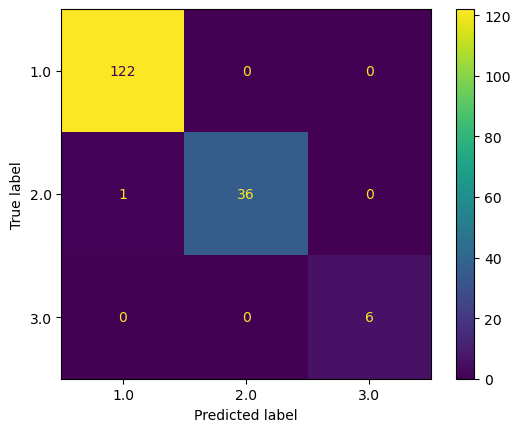

In [13]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp_dif, y_imp_dif, stratify = y_imp_dif, test_size=0.2, random_state=42)

model = MLPClassifier(solver='lbfgs', alpha=0.0001, max_iter = 500,
                    hidden_layer_sizes=(100,), learning_rate_init = 0.001, random_state=1)
clf = make_pipeline(StandardScaler(), model)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
clf.predict_proba(X_test)

# Evaluate the model
cross_val_scores = cross_val_score(clf, X_imp_dif, y_imp_dif, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))

print('SVM', ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test))

In [10]:
param_grid = [
     {'solver' : ['lbfgs'],
      'alpha' : [0.0001, 0.001, 0.01, 0.1],
      'learning_rate_init' : [0.001, 0.01, 0.1],
      'max_iter' : [500, 600, 700],
      'beta_1' : [0.9, 0.8, 0.7],
      'beta_2' : [0.999, 0.995, 0.990]
     }
]

grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed t

the best score was 0.9406315058986815
the best parameters were {'alpha': 0.01, 'beta_1': 0.9, 'beta_2': 0.999, 'learning_rate_init': 0.001, 'max_iter': 700, 'solver': 'lbfgs'}


C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_beta_1,param_beta_2,param_learning_rate_init,param_max_iter,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.709391,0.045357,0.005753,0.005521,0.0001,0.9,0.999,0.001,500,lbfgs,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.886364,0.931298,0.900763,0.954198,0.923664,0.919257,0.023704,298
1,0.876404,0.070375,0.005875,0.006759,0.0001,0.9,0.999,0.001,600,lbfgs,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.878788,0.938931,0.931298,0.954198,0.923664,0.925376,0.025389,190
2,1.056240,0.085010,0.005833,0.005219,0.0001,0.9,0.999,0.001,700,lbfgs,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.878788,0.931298,0.923664,0.954198,0.916031,0.920796,0.024583,244
3,0.819223,0.082307,0.002156,0.001253,0.0001,0.9,0.999,0.010,500,lbfgs,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.886364,0.931298,0.900763,0.954198,0.923664,0.919257,0.023704,298
4,0.951622,0.084098,0.002493,0.000451,0.0001,0.9,0.999,0.010,600,lbfgs,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.878788,0.938931,0.931298,0.954198,0.923664,0.925376,0.025389,190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,0.988292,0.030935,0.002005,0.001793,0.1000,0.7,0.990,0.010,600,lbfgs,"{'alpha': 0.1, 'beta_1': 0.7, 'beta_2': 0.99, ...",0.878788,0.946565,0.923664,0.969466,0.961832,0.936063,0.032632,28
320,1.092524,0.038780,0.007832,0.006798,0.1000,0.7,0.990,0.010,700,lbfgs,"{'alpha': 0.1, 'beta_1': 0.7, 'beta_2': 0.99, ...",0.878788,0.946565,0.923664,0.969466,0.961832,0.936063,0.032632,28
321,0.966121,0.054872,0.004394,0.006166,0.1000,0.7,0.990,0.100,500,lbfgs,"{'alpha': 0.1, 'beta_1': 0.7, 'beta_2': 0.99, ...",0.871212,0.946565,0.931298,0.969466,0.946565,0.933021,0.033222,82
322,1.124403,0.073426,0.002092,0.002610,0.1000,0.7,0.990,0.100,600,lbfgs,"{'alpha': 0.1, 'beta_1': 0.7, 'beta_2': 0.99, ...",0.878788,0.946565,0.923664,0.969466,0.961832,0.936063,0.032632,28


In [15]:
param_grid = [
     {'solver' : ['lbfgs'],
      'alpha' : [0.01],
      'learning_rate_init' : [0.001],
      'max_iter' : [700, 800, 900, 1000],
      'beta_1' : [0.9],
      'beta_2' : [0.999]
     }
]

grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed t

the best score was 0.9452000925283368
the best parameters were {'alpha': 0.01, 'beta_1': 0.9, 'beta_2': 0.999, 'learning_rate_init': 0.001, 'max_iter': 800, 'solver': 'lbfgs'}


C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_beta_1,param_beta_2,param_learning_rate_init,param_max_iter,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.999136,0.066950,0.008247,0.008610,0.01,0.9,0.999,0.001,700,lbfgs,"{'alpha': 0.01, 'beta_1': 0.9, 'beta_2': 0.999...",0.886364,0.938931,0.961832,0.977099,0.938931,0.940632,0.030758,3
1,1.128130,0.099071,0.001432,0.001218,0.01,0.9,0.999,0.001,800,lbfgs,"{'alpha': 0.01, 'beta_1': 0.9, 'beta_2': 0.999...",0.893939,0.969466,0.954198,0.946565,0.961832,0.945200,0.026743,1
2,1.281988,0.105180,0.002001,0.001796,0.01,0.9,0.999,0.001,900,lbfgs,"{'alpha': 0.01, 'beta_1': 0.9, 'beta_2': 0.999...",0.886364,0.946565,0.954198,0.969466,0.954198,0.942158,0.028872,2
3,1.595334,0.183251,0.002346,0.001450,0.01,0.9,0.999,0.001,1000,lbfgs,"{'alpha': 0.01, 'beta_1': 0.9, 'beta_2': 0.999...",0.886364,0.946565,0.954198,0.961832,0.946565,0.939105,0.026971,4


In [21]:
param_grid = [
     {'solver' : ['lbfgs'],
      'alpha' : [0.0001, 0.001, 0.01, 0.1],
      'learning_rate_init' : [0.001, 0.01, 0.1],
      'max_iter' : [500, 600, 700],
      'beta_1' : [0.9, 0.8, 0.7],
      'beta_2' : [0.999, 0.995, 0.990]
     }
]

grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_imp_dif, y_imp_dif)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed t

the best score was 0.9524759793052475
the best parameters were {'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.999, 'learning_rate_init': 0.001, 'max_iter': 700, 'solver': 'lbfgs'}


C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_beta_1,param_beta_2,param_learning_rate_init,param_max_iter,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.996269,0.380011,0.005452,0.004717,0.0001,0.9,0.999,0.001,500,lbfgs,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.963636,0.914634,0.926829,0.920732,0.939024,0.932971,0.017325,190
1,0.929321,0.054939,0.004932,0.005627,0.0001,0.9,0.999,0.001,600,lbfgs,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.981818,0.926829,0.951220,0.920732,0.939024,0.943925,0.021649,28
2,1.098628,0.095165,0.002756,0.000923,0.0001,0.9,0.999,0.001,700,lbfgs,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.969697,0.951220,0.963415,0.939024,0.939024,0.952476,0.012487,1
3,0.892556,0.096779,0.002604,0.001499,0.0001,0.9,0.999,0.010,500,lbfgs,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.963636,0.914634,0.926829,0.920732,0.939024,0.932971,0.017325,190
4,0.951378,0.096061,0.002756,0.001569,0.0001,0.9,0.999,0.010,600,lbfgs,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.981818,0.926829,0.951220,0.920732,0.939024,0.943925,0.021649,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,1.119687,0.032080,0.006034,0.005288,0.1000,0.7,0.990,0.010,600,lbfgs,"{'alpha': 0.1, 'beta_1': 0.7, 'beta_2': 0.99, ...",0.963636,0.926829,0.920732,0.920732,0.945122,0.935410,0.016707,163
320,1.301916,0.054889,0.002994,0.000879,0.1000,0.7,0.990,0.010,700,lbfgs,"{'alpha': 0.1, 'beta_1': 0.7, 'beta_2': 0.99, ...",0.957576,0.932927,0.957317,0.914634,0.932927,0.939076,0.016420,82
321,0.919036,0.046091,0.002809,0.002046,0.1000,0.7,0.990,0.100,500,lbfgs,"{'alpha': 0.1, 'beta_1': 0.7, 'beta_2': 0.99, ...",0.945455,0.914634,0.932927,0.914634,0.920732,0.925676,0.011934,271
322,1.091716,0.041363,0.002756,0.000922,0.1000,0.7,0.990,0.100,600,lbfgs,"{'alpha': 0.1, 'beta_1': 0.7, 'beta_2': 0.99, ...",0.963636,0.926829,0.920732,0.920732,0.945122,0.935410,0.016707,163


cross validation scores SVM: [0.98181818 0.98780488 0.98170732 0.98170732 0.97560976]
0.9817 accuracy with a standard deviation of 0.0039
Accuracy: 99.39%
SVM               precision    recall  f1-score   support

         1.0       0.99      1.00      1.00       122
         2.0       1.00      0.97      0.99        37
         3.0       1.00      1.00      1.00         6

    accuracy                           0.99       165
   macro avg       1.00      0.99      0.99       165
weighted avg       0.99      0.99      0.99       165

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000001E2E2768BE0>


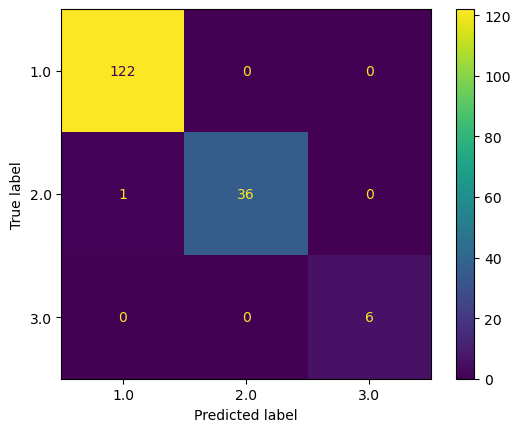

In [20]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp_dif, y_imp_dif, stratify = y_imp_dif, test_size=0.2, random_state=42)

model = MLPClassifier(solver='lbfgs', alpha=0.0001, max_iter = 800,
                    hidden_layer_sizes=(100,), learning_rate_init = 0.001, random_state=1)
clf = make_pipeline(StandardScaler(), model)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
clf.predict_proba(X_test)

# Evaluate the model
cross_val_scores = cross_val_score(clf, X_imp_dif, y_imp_dif, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))

print('SVM', ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test))